Learning 2D UDFs values through Neural Networks

In [1]:
import random
import warnings
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [2]:
## 2D Domain 

xmin, xmax = -2.0, 2.0
ymin, ymax = -2.0, 2.0

N_grid = 300

x = np.linspace(xmin, xmax, N_grid)
y = np.linspace(ymin, ymax, N_grid)
X, Y = np.meshgrid(x, y)

P_grid = np.stack([X, Y], axis=-1)

In [3]:
# Analytic 2D shape
# 2 circles union

c1 = np.array([-0.55, 0.0], dtype=np.float32)
c2 = np.array([ 0.55, 0.0], dtype=np.float32)
r1 = 0.75
r2 = 0.75


def udf_circle(points, center, radius):
    # UDF circle
    return np.abs(np.linalg.norm(points - center, axis=-1) - radius)


def udf_union_two_circles(points):
    # UDF of the union approximated by minimum between the two distances
    d1 = udf_circle(points, c1, r1)
    d2 = udf_circle(points, c2, r2)
    return np.minimum(d1, d2)

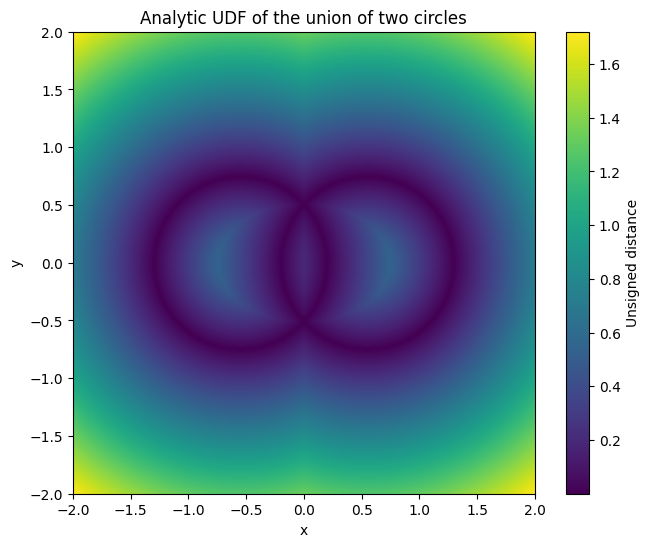

In [4]:
# Visualize the analytic UDF

U_true = udf_union_two_circles(P_grid)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    U_true,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap="viridis"
)

# True surface = zero level set
ax.contour(
    X,
    Y,
    U_true,
    levels=[0.0],
    colors="red",
    linewidths=2.5
)

ax.set_title("Analytic UDF of the union of two circles")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

plt.colorbar(im, ax=ax, label="Unsigned distance")
plt.show()

In [5]:
# Sample training points
# Uniformly sample points in the 2D domain and use the analytic UDF as supervision.

N_train = 8000
N_val = 2000

train_points = np.random.uniform(
    low=[xmin, ymin],
    high=[xmax, ymax],
    size=(N_train, 2)
).astype(np.float32)

val_points = np.random.uniform(
    low=[xmin, ymin],
    high=[xmax, ymax],
    size=(N_val, 2)
).astype(np.float32)

train_udf = udf_union_two_circles(train_points).astype(np.float32)[:, None]
val_udf = udf_union_two_circles(val_points).astype(np.float32)[:, None]

print("train_points:", train_points.shape)
print("val_points:  ", val_points.shape)

train_points: (8000, 2)
val_points:   (2000, 2)


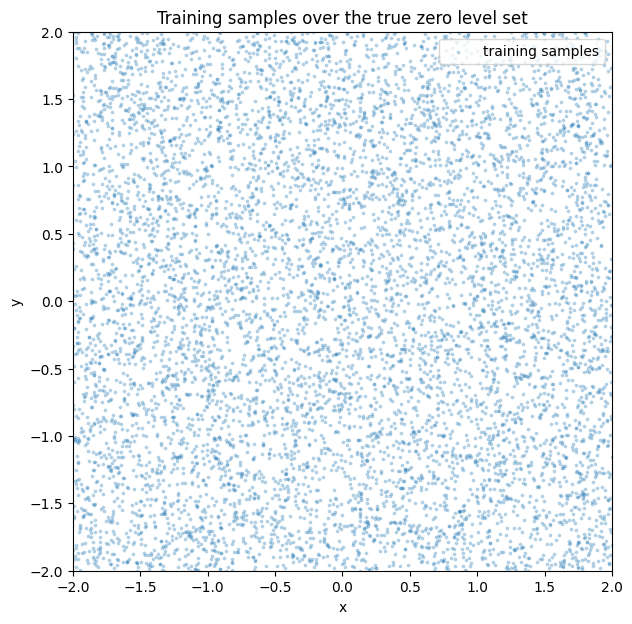

In [6]:
# Plot the sampled training points


fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    train_points[:, 0],
    train_points[:, 1],
    s=3,
    alpha=0.25,
    label="training samples"
)

ax.contour(
    X,
    Y,
    U_true,
    levels=[0.0],
    colors="red",
    linewidths=2.0
)

ax.set_title("Training samples over the true zero level set")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.legend()
plt.show()

In [7]:
# Convert data to torch tensors

x_train = torch.from_numpy(train_points).to(device)
y_train = torch.from_numpy(train_udf).to(device)

x_val = torch.from_numpy(val_points).to(device)
y_val = torch.from_numpy(val_udf).to(device)

In [8]:
# Define a small MLP for UDF regression

class NeuralUDF(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=128, num_hidden_layers=3):
        super().__init__()

        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.ReLU())

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(hidden_dim, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # Scalar output
        return torch.nn.functional.softplus(self.net(x))


model = NeuralUDF().to(device)
print(model)

NeuralUDF(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): ReLU()
    (6): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [9]:
# Loss and optimizer

criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 800
batch_size = 512

train_losses = []
val_losses = []

In [10]:
# Training loop

num_train = x_train.shape[0]

for epoch in range(num_epochs):
    model.train()

    perm = torch.randperm(num_train, device=device)
    epoch_loss = 0.0

    for i in range(0, num_train, batch_size):
        idx = perm[i:i + batch_size]

        xb = x_train[idx]
        yb = y_train[idx]

        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.shape[0]

    epoch_loss /= num_train

    model.eval()
    with torch.no_grad():
        val_pred = model(x_val)
        val_loss = criterion(val_pred, y_val).item()

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)

    if epoch % 100 == 0 or epoch == num_epochs - 1:
        print(
            f"epoch {epoch:04d} | "
            f"train_loss = {epoch_loss:.6f} | "
            f"val_loss = {val_loss:.6f}"
        )

epoch 0000 | train_loss = 0.301619 | val_loss = 0.193464
epoch 0100 | train_loss = 0.036304 | val_loss = 0.032846
epoch 0200 | train_loss = 0.010299 | val_loss = 0.012734
epoch 0300 | train_loss = 0.007742 | val_loss = 0.009519
epoch 0400 | train_loss = 0.006798 | val_loss = 0.007850
epoch 0500 | train_loss = 0.009476 | val_loss = 0.009712
epoch 0600 | train_loss = 0.006661 | val_loss = 0.009604
epoch 0700 | train_loss = 0.004544 | val_loss = 0.005878
epoch 0799 | train_loss = 0.005476 | val_loss = 0.006126


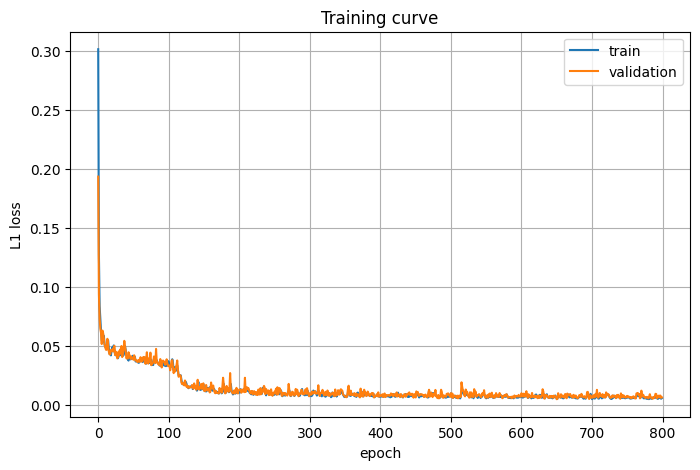

In [11]:
# Plot training curves

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(train_losses, label="train")
ax.plot(val_losses, label="validation")

ax.set_title("Training curve")
ax.set_xlabel("epoch")
ax.set_ylabel("L1 loss")
ax.legend()
ax.grid(True)

plt.show()

In [12]:
# Predict the learned UDF on the 2D grid

grid_points = P_grid.reshape(-1, 2).astype(np.float32)
grid_tensor = torch.from_numpy(grid_points).to(device)

model.eval()
with torch.no_grad():
    U_pred = model(grid_tensor).cpu().numpy().reshape(N_grid, N_grid)

U_error = np.abs(U_pred - U_true)

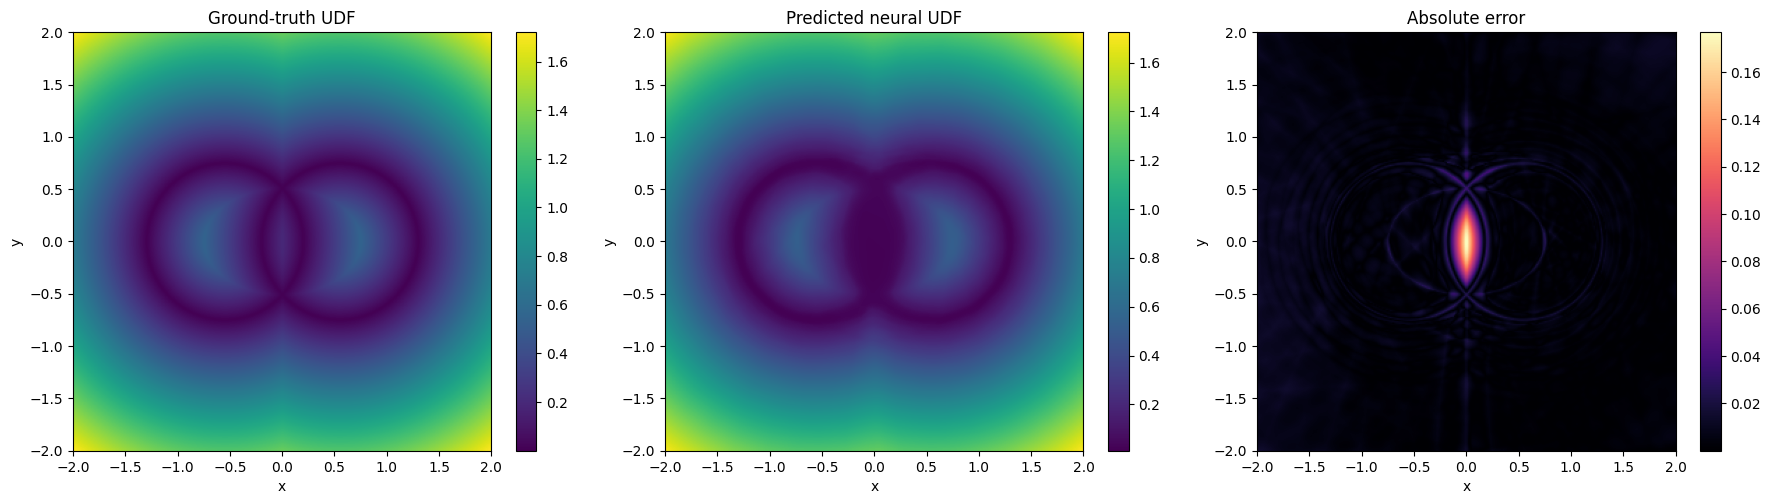

In [ ]:
# Compare true UDF, predicted UDF and absolute error

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# UDF real
im0 = axes[0].imshow(
    U_true,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap="viridis"
)
axes[0].contour(X, Y, U_true, levels=[0.0], colors="red", linewidths=2.0)
axes[0].set_title("Ground-truth UDF")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(
    U_pred,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap="viridis"
)
axes[1].contour(X, Y, U_pred, levels=[0.0], colors="red", linewidths=2.0)
axes[1].set_title("Predicted neural UDF")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(
    U_error,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap="magma"
)
axes[2].contour(X, Y, U_true, levels=[0.0], colors="cyan", linewidths=1.5)
axes[2].set_title("Absolute error")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].set_aspect("equal")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

In [14]:
# Compute the gradient of the neural UDF with autograd

sample_step = 12

Xs = X[::sample_step, ::sample_step]
Ys = Y[::sample_step, ::sample_step]

sample_points = np.stack([Xs, Ys], axis=-1).reshape(-1, 2).astype(np.float32)
sample_tensor = torch.from_numpy(sample_points).to(device)
sample_tensor.requires_grad_(True)

model.eval()
sample_values = model(sample_tensor)

grads = torch.autograd.grad(
    outputs=sample_values,
    inputs=sample_tensor,
    grad_outputs=torch.ones_like(sample_values),
    create_graph=False,
    retain_graph=False
)[0]

grads_np = grads.detach().cpu().numpy()
grad_x = grads_np[:, 0].reshape(Xs.shape)
grad_y = grads_np[:, 1].reshape(Ys.shape)

grad_norm = np.sqrt(grad_x**2 + grad_y**2) + 1e-8

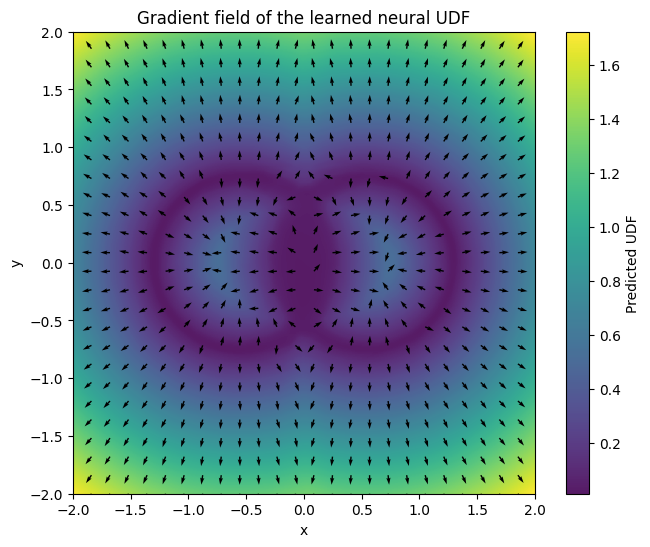

In [15]:
# Visualize the gradient field of the neural UDF

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    U_pred,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap="viridis",
    alpha=0.9
)

ax.contour(
    X,
    Y,
    U_true,
    levels=[0.0],
    colors="red",
    linewidths=2.0
)

ax.quiver(
    Xs,
    Ys,
    grad_x / grad_norm,
    grad_y / grad_norm,
    angles="xy",
    scale_units="xy",
    scale=12,
    width=0.003
)

ax.set_title("Gradient field of the learned neural UDF")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

plt.colorbar(im, ax=ax, label="Predicted UDF")
plt.show()

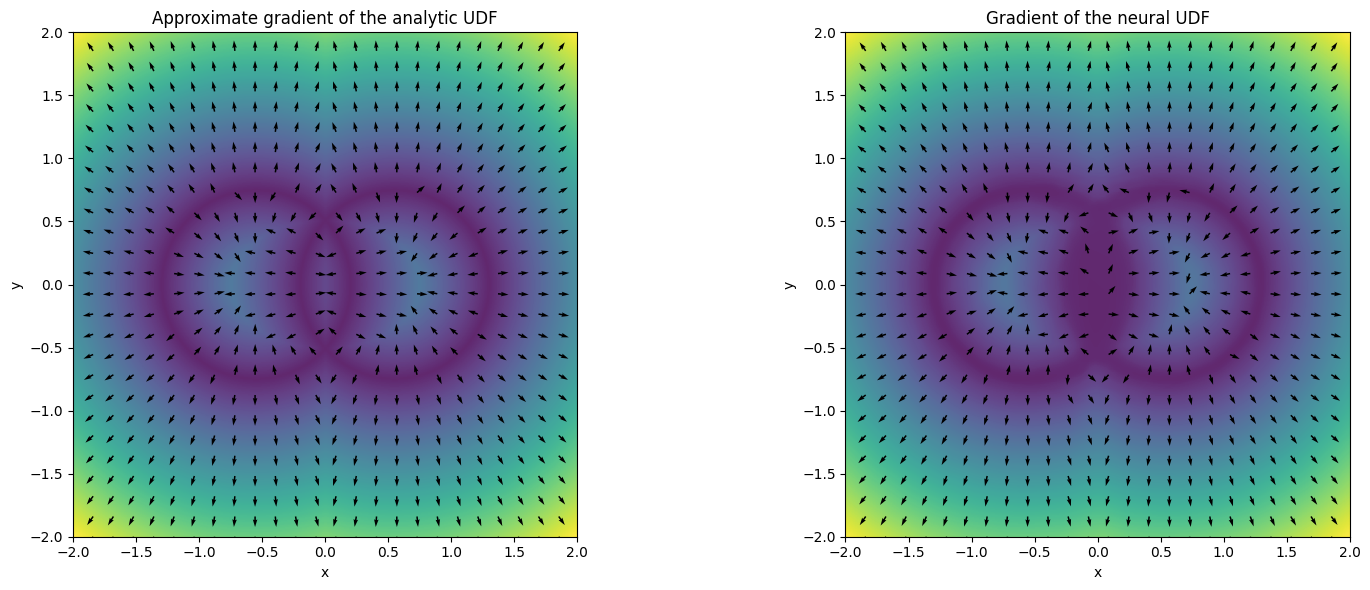

In [ ]:
# Finite-difference gradient of the true UDF

dx = x[1] - x[0]
dy = y[1] - y[0]

dU_true_dy, dU_true_dx = np.gradient(U_true, dy, dx)
true_grad_norm = np.sqrt(dU_true_dx**2 + dU_true_dy**2) + 1e-8

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(
    U_true,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap="viridis",
    alpha=0.85
)
axes[0].contour(X, Y, U_true, levels=[0.0], colors="red", linewidths=2.0)
axes[0].quiver(
    X[::sample_step, ::sample_step],
    Y[::sample_step, ::sample_step],
    dU_true_dx[::sample_step, ::sample_step] / true_grad_norm[::sample_step, ::sample_step],
    dU_true_dy[::sample_step, ::sample_step] / true_grad_norm[::sample_step, ::sample_step],
    angles="xy",
    scale_units="xy",
    scale=12,
    width=0.003
)
axes[0].set_title("Approximate gradient of the analytic UDF")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_aspect("equal")

axes[1].imshow(
    U_pred,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap="viridis",
    alpha=0.85
)
axes[1].contour(X, Y, U_true, levels=[0.0], colors="red", linewidths=2.0)
axes[1].quiver(
    Xs,
    Ys,
    grad_x / grad_norm,
    grad_y / grad_norm,
    angles="xy",
    scale_units="xy",
    scale=12,
    width=0.003
)
axes[1].set_title("Gradient of the neural UDF")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

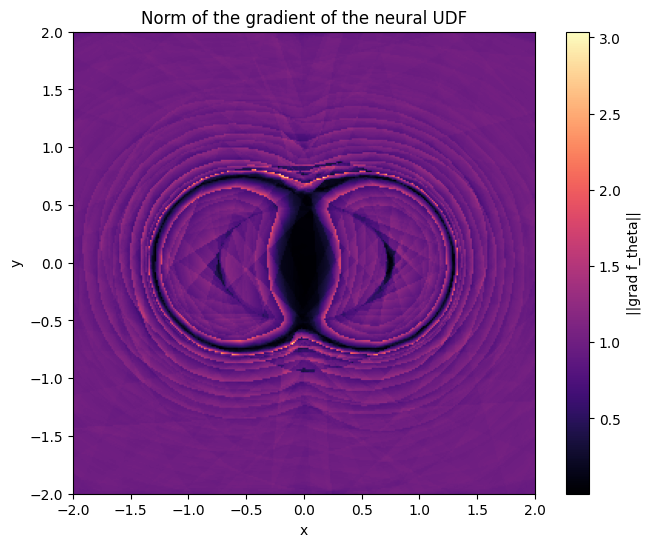

In [ ]:
# Gradient norm map of the neural UDF
# At an ideal distance, the gradient behavior is important.
# Here we want to visualize where the network produces more stable
# or more irregular gradients.

grid_for_grad = torch.from_numpy(grid_points).to(device)
grid_for_grad.requires_grad_(True)

grid_values = model(grid_for_grad)

grid_grads = torch.autograd.grad(
    outputs=grid_values,
    inputs=grid_for_grad,
    grad_outputs=torch.ones_like(grid_values),
    create_graph=False,
    retain_graph=False
)[0]

grid_grad_norm = torch.norm(grid_grads, dim=1).detach().cpu().numpy().reshape(N_grid, N_grid)

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(
    grid_grad_norm,
    extent=[xmin, xmax, ymin, ymax],
    origin="lower",
    cmap="magma"
)

ax.contour(
    X,
    Y,
    U_true,
    levels=[0.0],
    colors="cyan",
    linewidths=2.0
)

ax.set_title("Norm of the gradient of the neural UDF")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")

plt.colorbar(im, ax=ax, label="||grad f_theta||")
plt.show()

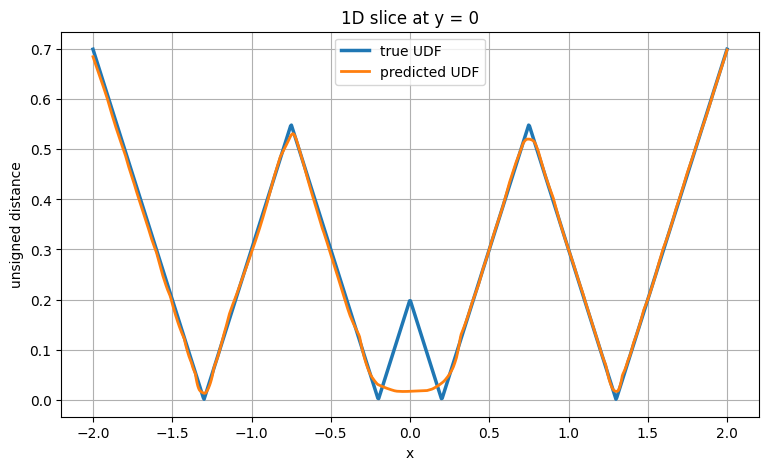

In [ ]:

# 1D slice through the field

x_line = np.linspace(xmin, xmax, 800, dtype=np.float32)
y_line = np.zeros_like(x_line, dtype=np.float32)

line_points = np.stack([x_line, y_line], axis=-1)
line_true = udf_union_two_circles(line_points)

line_tensor = torch.from_numpy(line_points).to(device)
with torch.no_grad():
    line_pred = model(line_tensor).cpu().numpy().squeeze()

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(x_line, line_true, label="true UDF", linewidth=2.5)
ax.plot(x_line, line_pred, label="predicted UDF", linewidth=2.0)

ax.set_title("1D slice at y = 0")
ax.set_xlabel("x")
ax.set_ylabel("unsigned distance")
ax.grid(True)
ax.legend()

plt.show()